# ============================================================
# NOTEBOOK: match_mirai_v2.ipynb
# Mirai — Matching entre CIC, Nemea, Tstat y Tshark
# ============================================================
#
# PARTICULARIDADES MIRAI:
#   1. Nemea: IPs pueden venir sin puntos → reconstruir_ip
#   2. Nemea: timestamps con coma decimal → .str.replace(',','.')
#   3. Nemea: CSV único → columna de etiqueta detectada dinámicamente
#      (última columna del CSV, valor esperado: 'Mirai')
#   4. CIC / Tstat / Tshark: múltiples CSVs en carpeta → glob
# ============================================================

In [1]:
# ============================================================
# CELDA 0 — IMPORTS GLOBALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('\u2713 Imports OK')
print(f'  pandas:  {pd.__version__}')
print(f'  numpy:   {np.__version__}')

✓ Imports OK
  pandas:  2.2.0
  numpy:   1.26.4


In [2]:
# ============================================================
# CELDA 0.1 — FUNCIÓN reconstruir_ip
# PARTICULARIDAD MIRAI: Nemea a veces guarda IPs sin puntos
# ============================================================

def reconstruir_ip(ip):
    if pd.isna(ip):
        return ip
    s = str(ip).strip()
    if '.' in s:
        return s
    if not s.isdigit():
        return s
    resultados = []
    def backtrack(resto, partes):
        if len(partes) == 4:
            if resto == '':
                resultados.append(partes[:])
            return
        for i in range(1, 4):
            if i > len(resto):
                break
            trozo = resto[:i]
            if len(trozo) > 1 and trozo[0] == '0':
                continue
            if 0 <= int(trozo) <= 255:
                partes.append(trozo)
                backtrack(resto[i:], partes)
                partes.pop()
    backtrack(s, [])
    return '.'.join(resultados[0]) if resultados else s

print('Test reconstruir_ip:')
print(f"  '192168001001' \u2192 {reconstruir_ip('192168001001')}")
print(f"  '192.168.0.1'  \u2192 {reconstruir_ip('192.168.0.1')}  (ya tiene puntos)")
print(f"  '10001001'     \u2192 {reconstruir_ip('10001001')}")

Test reconstruir_ip:
  '192168001001' → 192168001001
  '192.168.0.1'  → 192.168.0.1  (ya tiene puntos)
  '10001001'     → 100.0.100.1


# CICFlowMeter

In [3]:
# ============================================================
# CELDA 1.1 — CARGA DE CIC
# Mirai tiene varios subtipos en carpeta → glob
# ============================================================

RUTA_CIC = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/Mirai')
print(f'Ruta CIC: {RUTA_CIC}')
print(f'Existe:   {RUTA_CIC.exists()}')
print()

csv_files = sorted(RUTA_CIC.glob('*.csv'))
print(f'CSVs encontrados: {len(csv_files)}')

if not csv_files:
    raise FileNotFoundError(f'No se encontraron CSVs en: {RUTA_CIC}')

dfs = []
for f in csv_files:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen'] = f.stem
    dfs.append(df_temp)
    print(f'  \u2713 {f.name:50s} \u2192 {len(df_temp):>8,} filas')

df_cic = pd.concat(dfs, ignore_index=True)

print()
print(f'Shape total CIC: {df_cic.shape}')
print(f'NaNs totales:    {df_cic.isnull().sum().sum():,}')

Ruta CIC: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/Mirai
Existe:   True

CSVs encontrados: 76
  ✓ Mirai-greeth_flood.pcap_Flow.csv                   →    5,172 filas
  ✓ Mirai-greeth_flood1.pcap_Flow.csv                  →   10,856 filas
  ✓ Mirai-greeth_flood10.pcap_Flow.csv                 →    8,187 filas
  ✓ Mirai-greeth_flood11.pcap_Flow.csv                 →    8,377 filas
  ✓ Mirai-greeth_flood12.pcap_Flow.csv                 →    6,423 filas
  ✓ Mirai-greeth_flood13.pcap_Flow.csv                 →   10,306 filas
  ✓ Mirai-greeth_flood14.pcap_Flow.csv                 →    2,977 filas
  ✓ Mirai-greeth_flood15.pcap_Flow.csv                 →    3,247 filas
  ✓ Mirai-greeth_flood16.pcap_Flow.csv                 →    4,438 filas
  ✓ Mirai-greeth_flood17.pcap_Flow.csv                 →    2,790 filas
  ✓ Mirai-greeth_flood18.pcap_Flow.csv                 →    3,265 filas
  ✓ Mirai-greeth_flood19.pcap_Flow.csv                 →    3,481 filas
  ✓ Mirai-greeth_flood2.pcap_Flo

In [4]:
# ============================================================
# CELDA 1.2 — LIMPIEZA Y NORMALIZACIÓN CIC
# ============================================================

df_cic['Timestamp'] = (
    df_cic['Timestamp'].astype(str)
    .str.replace(' p. m.', ' PM', regex=False)
    .str.replace(' a. m.', ' AM', regex=False)
    .str.strip()
)
df_cic['Timestamp'] = pd.to_datetime(
    df_cic['Timestamp'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce'
)

nat_count = df_cic['Timestamp'].isna().sum()
print(f'NaT en Timestamp: {nat_count}')
if nat_count > 0:
    df_cic = df_cic.dropna(subset=['Timestamp']).reset_index(drop=True)

df_cic['Protocol']      = pd.to_numeric(df_cic['Protocol'],      errors='coerce').fillna(0).astype(int)
df_cic['Src Port']      = pd.to_numeric(df_cic['Src Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Dst Port']      = pd.to_numeric(df_cic['Dst Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Flow Duration'] = pd.to_numeric(df_cic['Flow Duration'], errors='coerce')

print(f'\nShape CIC limpio: {df_cic.shape}')
print(f'\nRango temporal CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')
print(f'\nDistribución por protocolo:')
print(df_cic['Protocol'].value_counts().to_string())
print(f'\nDistribución por subtipo (archivo origen):')
print(df_cic['archivo_origen'].value_counts().to_string())

NaT en Timestamp: 0

Shape CIC limpio: (560668, 85)

Rango temporal CIC:
  Min: 2022-12-19 17:23:00
  Max: 2023-02-14 18:37:57

Distribución por protocolo:
Protocol
17    401260
6     143039
0      16369

Distribución por subtipo (archivo origen):
archivo_origen
Mirai-greip_flood8.pcap_Flow      22507
Mirai-greip_flood18.pcap_Flow     21395
Mirai-greip_flood4.pcap_Flow      16576
Mirai-greip_flood13.pcap_Flow     16086
Mirai-greip_flood6.pcap_Flow      15915
Mirai-greip_flood10.pcap_Flow     12370
Mirai-greeth_flood9.pcap_Flow     12079
Mirai-greeth_flood6.pcap_Flow     11786
Mirai-greip_flood14.pcap_Flow     11646
Mirai-udpplain9.pcap_Flow         11540
Mirai-greip_flood17.pcap_Flow     11503
Mirai-greip_flood19.pcap_Flow     11127
Mirai-greeth_flood1.pcap_Flow     10856
Mirai-greip_flood.pcap_Flow       10493
Mirai-greip_flood7.pcap_Flow      10349
Mirai-greeth_flood13.pcap_Flow    10306
Mirai-greip_flood16.pcap_Flow     10278
Mirai-udpplain3.pcap_Flow         10010
Mirai-greip_flood

In [5]:
# ============================================================
# CELDA 1.3 — KEY BASE Y KEY EXACT CIC
# ============================================================

df_cic['time_sec']    = df_cic['Timestamp'].dt.floor('s')
df_cic['flow_dur_ms'] = (df_cic['Flow Duration'] / 1000).round().astype('Int64')

df_cic['key_base'] = list(zip(
    df_cic['Src IP'].astype(str),
    df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),
    df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str),
    df_cic['time_sec'].astype(str)
))
df_cic['key_exact'] = list(zip(
    df_cic['Src IP'].astype(str),
    df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),
    df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str),
    df_cic['time_sec'].astype(str),
    df_cic['flow_dur_ms'].astype(str)
))

print(f'Shape CIC: {df_cic.shape}')
print(f'Claves base únicas: {df_cic["key_base"].nunique():,}')

Shape CIC: (560668, 89)
Claves base únicas: 554,856


In [6]:
# ============================================================
# CELDA 1.4 — ANÁLISIS DE COLISIONES CIC
# ============================================================

conteo          = df_cic.groupby('key_base').size()
total_claves    = len(conteo)
claves_unicas   = (conteo == 1).sum()
claves_colision = (conteo > 1).sum()
flujos_colision = conteo[conteo > 1].sum()
pct_colision    = round(claves_colision / total_claves * 100, 2)

print('=' * 60)
print('ANÁLISIS DE COLISIONES CIC — Mirai')
print('=' * 60)
print(f'  Total filas:                 {len(df_cic):,}')
print(f'  Total claves base únicas:    {total_claves:,}')
print(f'  Claves sin colisión:         {claves_unicas:,}  ({round(claves_unicas/total_claves*100,2)}%)')
print(f'  Claves con colisión:         {claves_colision:,}  ({pct_colision}%)')
print(f'  Flujos afectados:            {flujos_colision:,}')
print()
if pct_colision < 1:
    print(f'  \u2192 \u2713 SEGURO ({pct_colision}% colisiones)')
elif pct_colision < 5:
    print(f'  \u2192 ~ ACEPTABLE ({pct_colision}% colisiones)')
else:
    print(f'  \u2192 \u2717 RIESGO ({pct_colision}% colisiones)')

if claves_colision > 0:
    print('\n  Ejemplos de colisión:')
    for k in conteo[conteo > 1].index[:3]:
        df_col = df_cic[df_cic['key_base'] == k]
        print(f'\n  Clave: {k}')
        print(df_col[['Src IP','Src Port','Dst IP','Dst Port',
                       'Protocol','Timestamp','Flow Duration']].to_string(index=False))

ANÁLISIS DE COLISIONES CIC — Mirai
  Total filas:                 560,668
  Total claves base únicas:    554,856
  Claves sin colisión:         550,892  (99.29%)
  Claves con colisión:         3,964  (0.71%)
  Flujos afectados:            9,776

  → ✓ SEGURO (0.71% colisiones)

  Ejemplos de colisión:

  Clave: ('1.1.1.1', '443', '192.168.137.5', '48364', '6', '2022-12-19 19:43:02')
 Src IP  Src Port        Dst IP  Dst Port  Protocol           Timestamp  Flow Duration
1.1.1.1       443 192.168.137.5     48364         6 2022-12-19 19:43:02         310372
1.1.1.1       443 192.168.137.5     48364         6 2022-12-19 19:43:02         293100

  Clave: ('1.1.1.1', '53', '192.168.137.58', '9932', '6', '2023-01-17 16:29:22')
 Src IP  Src Port         Dst IP  Dst Port  Protocol           Timestamp  Flow Duration
1.1.1.1        53 192.168.137.58      9932         6 2023-01-17 16:29:22          26980
1.1.1.1        53 192.168.137.58      9932         6 2023-01-17 16:29:22        2697407

  Clav

# NEMEA

In [7]:
# ============================================================
# CELDA 2.1 — CARGA DE NEMEA
# Mirai: 3 CSVs (uno por subtipo) → glob igual que CIC
# Columna de etiqueta detectada dinámicamente (última columna)
# ============================================================

RUTA_NEMEA = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/Mirai')
print(f'Ruta Nemea: {RUTA_NEMEA}')
print(f'Existe:     {RUTA_NEMEA.exists()}')
print()

csv_files_nemea = sorted(RUTA_NEMEA.glob('*_Nemea.csv'))
print(f'CSVs Nemea encontrados: {len(csv_files_nemea)}')
for f in csv_files_nemea:
    print(f'  {f.name}')

if not csv_files_nemea:
    raise FileNotFoundError(f'No se encontraron CSVs Nemea en: {RUTA_NEMEA}')

# Detectar columna de etiqueta desde la cabecera del primer fichero
col_etiqueta_nemea = pd.read_csv(csv_files_nemea[0], nrows=0).columns[-1]
print(f'\nColumna de etiqueta detectada: \'{col_etiqueta_nemea}\'')

dfs_nemea = []
for f in csv_files_nemea:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen_nemea'] = f.stem   # guarda el subtipo
    dfs_nemea.append(df_temp)
    print(f'  ✓ {f.name:45s} → {len(df_temp):>8,} filas')

df_nemea = pd.concat(dfs_nemea, ignore_index=True)

print()
print(f'Shape Nemea total: {df_nemea.shape}')
print(f'NaNs:              {df_nemea.isnull().sum().sum():,}')
print(f'\nDistribución por subtipo:')
print(df_nemea['archivo_origen_nemea'].value_counts().to_string())
print(f'\nDistribución por protocolo:')
print(df_nemea['uint8 PROTOCOL'].value_counts().to_string())
print(f'\nDistribución por etiqueta ({col_etiqueta_nemea}):')
print(df_nemea[col_etiqueta_nemea].value_counts().to_string())

Ruta Nemea: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/Mirai
Existe:     True

CSVs Nemea encontrados: 3
  Mirai_greeth_flood_Nemea.csv
  Mirai_greip_flood_Nemea.csv
  Mirai_udpplain_Nemea.csv

Columna de etiqueta detectada: 'LABEL'
  ✓ Mirai_greeth_flood_Nemea.csv                  →  174,812 filas
  ✓ Mirai_greip_flood_Nemea.csv                   →  842,350 filas
  ✓ Mirai_udpplain_Nemea.csv                      →  420,477 filas

Shape Nemea total: (1437639, 207)
NaNs:              7,008,081

Distribución por subtipo:
archivo_origen_nemea
Mirai_greip_flood_Nemea     842350
Mirai_udpplain_Nemea        420477
Mirai_greeth_flood_Nemea    174812

Distribución por protocolo:
uint8 PROTOCOL
17    1281897
6      116425
1       28719
58       8187
2        2411

Distribución por etiqueta (LABEL):
LABEL
Mirai    1437639


In [8]:
# ============================================================
# CELDA 2.2 — LIMPIEZA Y NORMALIZACIÓN NEMEA
# PARTICULARIDADES MIRAI:
#   - IPs pueden venir sin puntos → reconstruir_ip
#   - Timestamps con coma decimal → .str.replace(',', '.')
# ============================================================

col_src_ip   = 'ipaddr SRC_IP'
col_dst_ip   = 'ipaddr DST_IP'
col_src_port = 'uint16 SRC_PORT'
col_dst_port = 'uint16 DST_PORT'
col_protocol = 'uint8 PROTOCOL'
col_t_first  = 'time TIME_FIRST'
col_t_last   = 'time TIME_LAST'

# Limpiar espacios en IPs
df_nemea[col_src_ip] = df_nemea[col_src_ip].astype(str).str.strip()
df_nemea[col_dst_ip] = df_nemea[col_dst_ip].astype(str).str.strip()

# Reconstruir IPs sin puntos
df_nemea['SRC_IP_norm'] = df_nemea[col_src_ip].apply(reconstruir_ip)
df_nemea['DST_IP_norm'] = df_nemea[col_dst_ip].apply(reconstruir_ip)

n_src_sin_punto = (~df_nemea[col_src_ip].str.contains('.', regex=False)).sum()
n_dst_sin_punto = (~df_nemea[col_dst_ip].str.contains('.', regex=False)).sum()
print(f'IPs SRC sin punto (antes de reconstruir): {n_src_sin_punto:,}')
print(f'IPs DST sin punto (antes de reconstruir): {n_dst_sin_punto:,}')
print()
print('Muestra de reconstrucción:')
print(df_nemea[[col_src_ip, 'SRC_IP_norm', col_dst_ip, 'DST_IP_norm']].head(5).to_string())

# Timestamps — coma decimal → punto
df_nemea['TIME_FIRST_limpio'] = df_nemea[col_t_first].astype(str).str.replace(',', '.', regex=False)
df_nemea['TIME_LAST_limpio']  = df_nemea[col_t_last].astype(str).str.replace(',', '.', regex=False)

df_nemea['TIME_FIRST_dt'] = pd.to_datetime(
    df_nemea['TIME_FIRST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)
df_nemea['TIME_LAST_dt'] = pd.to_datetime(
    df_nemea['TIME_LAST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)

# ── CAMBIO: UTC+1 (invierno CET) en lugar de UTC+2
df_nemea['TIME_FIRST_utc2'] = df_nemea['TIME_FIRST_dt'] + pd.Timedelta(hours=1)
df_nemea['TIME_LAST_utc2']  = df_nemea['TIME_LAST_dt']  + pd.Timedelta(hours=1)

# Duración
df_nemea['flow_dur_us'] = (
    (df_nemea['TIME_LAST_utc2'] - df_nemea['TIME_FIRST_utc2'])
    .dt.total_seconds() * 1_000_000
).round().astype('Int64')
df_nemea['flow_dur_ms'] = (df_nemea['flow_dur_us'] / 1000).round().astype('Int64')

# Protocolo numérico
df_nemea[col_protocol] = pd.to_numeric(
    df_nemea[col_protocol], errors='coerce'
).fillna(0).astype(int)

print(f'\nShape Nemea: {df_nemea.shape}')
print(f'NaT en TIME_FIRST_dt: {df_nemea["TIME_FIRST_dt"].isna().sum()}')
print(f'NaT en TIME_LAST_dt:  {df_nemea["TIME_LAST_dt"].isna().sum()}')
print(f'Rango temporal Nemea (UTC+1 | invierno CET):')
print(f'  Min TIME_FIRST: {df_nemea["TIME_FIRST_utc2"].min()}')
print(f'  Max TIME_LAST:  {df_nemea["TIME_LAST_utc2"].max()}')
print(f'\nRango CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')

IPs SRC sin punto (antes de reconstruir): 16,295
IPs DST sin punto (antes de reconstruir): 16,295

Muestra de reconstrucción:
     ipaddr SRC_IP      SRC_IP_norm    ipaddr DST_IP      DST_IP_norm
0    3.223.181.245    3.223.181.245  192.168.137.174  192.168.137.174
1  192.168.137.181  192.168.137.181     34.211.189.2     34.211.189.2
2  192.168.137.109  192.168.137.109  255.255.255.255  255.255.255.255
3  192.168.137.123  192.168.137.123  255.255.255.255  255.255.255.255
4   192.99.160.133   192.99.160.133  192.168.137.120  192.168.137.120

Shape Nemea: (1437639, 217)
NaT en TIME_FIRST_dt: 0
NaT en TIME_LAST_dt:  0
Rango temporal Nemea (UTC+1 | invierno CET):
  Min TIME_FIRST: 2022-12-19 17:23:00.400742
  Max TIME_LAST:  2023-02-14 18:38:00.630347

Rango CIC:
  Min: 2022-12-19 17:23:00
  Max: 2023-02-14 18:37:57


In [9]:
# ============================================================
# CELDA 2.3 — KEY BASE Y MATCHING CIC ∩ NEMEA
# ============================================================

df_nemea['time_sec'] = df_nemea['TIME_FIRST_utc2'].dt.floor('s')

df_nemea['key_base_dir'] = list(zip(
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str)
))
df_nemea['key_base_inv'] = list(zip(
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str)
))
df_nemea['key_exact_dir'] = list(zip(
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))
df_nemea['key_exact_inv'] = list(zip(
    df_nemea['DST_IP_norm'].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea['SRC_IP_norm'].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str),  df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))

cic_keys_base  = set(df_cic['key_base'])
cic_keys_exact = set(df_cic['key_exact'])

nemea_base_dir  = set(df_nemea['key_base_dir'])
nemea_base_inv  = set(df_nemea['key_base_inv'])
nemea_exact_dir = set(df_nemea['key_exact_dir'])
nemea_exact_inv = set(df_nemea['key_exact_inv'])

match_nemea_base  = cic_keys_base  & (nemea_base_dir  | nemea_base_inv)
match_nemea_exact = cic_keys_exact & (nemea_exact_dir | nemea_exact_inv)

print('=' * 60)
print('MATCHING CIC \u2229 NEMEA — Mirai')
print('=' * 60)
print(f'  CIC total flujos:            {len(df_cic):,}')
print(f'  Nemea total flujos:          {len(df_nemea):,}')
print(f'  CIC claves base únicas:      {len(cic_keys_base):,}')
print(f'  Nemea claves base únicas:    {len(nemea_base_dir):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_nemea_base):,}')
print(f'  Match EXACTO (con dur. ms):  {len(match_nemea_exact):,}')
print(f'  Diferencia:                  {len(match_nemea_base) - len(match_nemea_exact):,}')
print()
print(f'  % match base sobre CIC:      {round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%')
print(f'  % match exacto sobre CIC:    {round(len(match_nemea_exact)/len(cic_keys_base)*100,2)}%')

MATCHING CIC ∩ NEMEA — Mirai
  CIC total flujos:            560,668
  Nemea total flujos:          1,437,639
  CIC claves base únicas:      554,856
  Nemea claves base únicas:    1,157,316

  Match BASE (sin duración):   261,262
  Match EXACTO (con dur. ms):  228,132
  Diferencia:                  33,130

  % match base sobre CIC:      47.09%
  % match exacto sobre CIC:    41.12%


# TSTAT

In [10]:
# ============================================================
# CELDA 3.1 — CARGA DE TSTAT
# Mirai tiene varios subtipos → glob igual que CIC
# ============================================================

RUTA_TSTAT = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/Mirai')
print(f'Ruta Tstat: {RUTA_TSTAT}')
print(f'Existe:     {RUTA_TSTAT.exists()}')
print()

csv_files_tstat = sorted(RUTA_TSTAT.glob('*.csv'))
print(f'CSVs encontrados: {len(csv_files_tstat)}')

dfs_tstat = []
for f in csv_files_tstat:
    df_temp = pd.read_csv(f, low_memory=False)
    dfs_tstat.append(df_temp)
    print(f'  \u2713 {f.name:40s} \u2192 {len(df_temp):>8,} filas')

df_tstat = pd.concat(dfs_tstat, ignore_index=True)

print()
print(f'Shape total Tstat: {df_tstat.shape}')
print(f'NaNs:              {df_tstat.isnull().sum().sum():,}')
print(f'\nDistribución por protocolo:')
print(df_tstat['protocolo'].value_counts().to_string())
print(f"\nFilas con first == 0: {(df_tstat['first'] == 0).sum():,}")
print(f"Filas con first > 0:  {(df_tstat['first'] > 0).sum():,}")

Ruta Tstat: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/Mirai
Existe:     True

CSVs encontrados: 72
  ✓ Mirai-greeth_flood.csv                   →      872 filas
  ✓ Mirai-greeth_flood1.csv                  →      137 filas
  ✓ Mirai-greeth_flood10.csv                 →      165 filas
  ✓ Mirai-greeth_flood11.csv                 →      307 filas
  ✓ Mirai-greeth_flood12.csv                 →      236 filas
  ✓ Mirai-greeth_flood13.csv                 →      203 filas
  ✓ Mirai-greeth_flood14.csv                 →      104 filas
  ✓ Mirai-greeth_flood15.csv                 →       77 filas
  ✓ Mirai-greeth_flood17.csv                 →      135 filas
  ✓ Mirai-greeth_flood18.csv                 →       76 filas
  ✓ Mirai-greeth_flood19.csv                 →      138 filas
  ✓ Mirai-greeth_flood2.csv                  →      121 filas
  ✓ Mirai-greeth_flood20.csv                 →       61 filas
  ✓ Mirai-greeth_flood21.csv                 →       72 filas
  ✓ Mirai-greeth_f

In [11]:
# ============================================================
# CELDA 3.2 — LIMPIEZA Y SEPARACIÓN TCP/UDP TSTAT
# ============================================================

df_tcp_tstat = df_tstat[df_tstat['protocolo'] == 'TCP'].copy()
df_udp_tstat = df_tstat[df_tstat['protocolo'] == 'UDP'].copy()
print(f'TCP total: {len(df_tcp_tstat):,}  | UDP total: {len(df_udp_tstat):,}')
print()

# ── TCP
df_tcp_tstat['first'] = pd.to_numeric(df_tcp_tstat['first'], errors='coerce')
n_antes = len(df_tcp_tstat)
df_tcp_tstat = df_tcp_tstat[df_tcp_tstat['first'] > 0].copy()
print(f'TCP válidos (first>0): {len(df_tcp_tstat):,}  (eliminados: {n_antes-len(df_tcp_tstat):,})')

df_tcp_tstat['first_dt']    = pd.to_datetime(df_tcp_tstat['first'], unit='ms', errors='coerce')
df_tcp_tstat['first_utc2']  = df_tcp_tstat['first_dt'] + pd.Timedelta(hours=1)
df_tcp_tstat['flow_dur_ms'] = df_tcp_tstat['durat'].round().astype('Int64')
df_tcp_tstat['flow_dur_us'] = (df_tcp_tstat['durat'] * 1000).round().astype('Int64')
df_tcp_tstat['proto_num']   = 6

# ── UDP
df_udp_tstat['c_first_abs'] = pd.to_numeric(df_udp_tstat['c_first_abs'], errors='coerce')
n_antes = len(df_udp_tstat)
df_udp_tstat = df_udp_tstat[df_udp_tstat['c_first_abs'] > 0].copy()
print(f'UDP válidos (c_first_abs>0): {len(df_udp_tstat):,}  (eliminados: {n_antes-len(df_udp_tstat):,})')

df_udp_tstat['first_dt']    = pd.to_datetime(df_udp_tstat['c_first_abs'], unit='ms', errors='coerce')
df_udp_tstat['first_utc2']  = df_udp_tstat['first_dt'] + pd.Timedelta(hours=1)
df_udp_tstat['c_durat']     = pd.to_numeric(df_udp_tstat['c_durat'], errors='coerce').fillna(0)
df_udp_tstat['s_durat']     = pd.to_numeric(df_udp_tstat['s_durat'], errors='coerce').fillna(0)
df_udp_tstat['flow_dur_ms'] = df_udp_tstat[['c_durat','s_durat']].max(axis=1).round().astype('Int64')
df_udp_tstat['flow_dur_us'] = (df_udp_tstat['flow_dur_ms'] * 1000).round().astype('Int64')
df_udp_tstat['proto_num']   = 17

print(f"\nUDP con duración > 0: {(df_udp_tstat['flow_dur_ms'] > 0).sum():,}")
print(f"UDP sin duración:     {(df_udp_tstat['flow_dur_ms'] == 0).sum():,}")

TCP total: 259  | UDP total: 8,902

TCP válidos (first>0): 259  (eliminados: 0)
UDP válidos (c_first_abs>0): 8,902  (eliminados: 0)

UDP con duración > 0: 3,047
UDP sin duración:     5,855


In [12]:
# ============================================================
# CELDA 3.3 — BASE UNIFICADA TSTAT
# ============================================================

cols_base_tstat = ['c_ip','c_port','s_ip','s_port','proto_num',
                   'first_utc2','flow_dur_us','flow_dur_ms']

df_tstat_base = pd.concat([
    df_tcp_tstat[cols_base_tstat],
    df_udp_tstat[cols_base_tstat]
], ignore_index=True)

df_tstat_base['time_sec'] = df_tstat_base['first_utc2'].dt.floor('s')

print(f'Shape Tstat base: {df_tstat_base.shape}')
print(f"  TCP: {(df_tstat_base['proto_num']==6).sum():,}")
print(f"  UDP: {(df_tstat_base['proto_num']==17).sum():,}")
print(f'\nRango temporal Tstat (UTC+2):')
print(f"  Min: {df_tstat_base['time_sec'].min()}")
print(f"  Max: {df_tstat_base['time_sec'].max()}")
print(f'\nRango CIC:')
print(f"  Min: {df_cic['Timestamp'].min()}")
print(f"  Max: {df_cic['Timestamp'].max()}")

Shape Tstat base: (9161, 9)
  TCP: 259
  UDP: 8,902

Rango temporal Tstat (UTC+2):
  Min: 2022-12-19 17:23:00
  Max: 2023-02-07 17:24:37

Rango CIC:
  Min: 2022-12-19 17:23:00
  Max: 2023-02-14 18:37:57


In [13]:
# ============================================================
# CELDA 3.4 — KEY BASE Y MATCHING CIC ∩ TSTAT
# ============================================================

df_tstat_base['key_base_dir'] = list(zip(
    df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
    df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
    df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
))
df_tstat_base['key_base_inv'] = list(zip(
    df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
    df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
    df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
))

df_tstat_dur = df_tstat_base[df_tstat_base['flow_dur_ms'] > 0].copy()
df_tstat_dur['key_exact_dir'] = list(zip(
    df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
    df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
    df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
    df_tstat_dur['flow_dur_ms'].astype(str)
))
df_tstat_dur['key_exact_inv'] = list(zip(
    df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
    df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
    df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
    df_tstat_dur['flow_dur_ms'].astype(str)
))

tstat_base_keys  = set(df_tstat_base['key_base_dir']) | set(df_tstat_base['key_base_inv'])
tstat_exact_keys = set(df_tstat_dur['key_exact_dir']) | set(df_tstat_dur['key_exact_inv'])

match_tstat_base  = cic_keys_base  & tstat_base_keys
match_tstat_exact = cic_keys_exact & tstat_exact_keys

print('=' * 60)
print('MATCHING CIC \u2229 TSTAT — Mirai')
print('=' * 60)
print(f'  Tstat total flujos:          {len(df_tstat_base):,}')
print(f'  Tstat con duración > 0:      {len(df_tstat_dur):,}')
print(f'  Tstat sin duración:          {len(df_tstat_base)-len(df_tstat_dur):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_tstat_base):,}')
print(f'  Match EXACTO (con dur. ms):  {len(match_tstat_exact):,}')
print(f'  Diferencia:                  {len(match_tstat_base)-len(match_tstat_exact):,}')
print()
print(f'  % match base sobre CIC:      {round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%')
print(f'  % match exacto sobre CIC:    {round(len(match_tstat_exact)/len(cic_keys_base)*100,2)}%')

MATCHING CIC ∩ TSTAT — Mirai
  Tstat total flujos:          9,161
  Tstat con duración > 0:      3,306
  Tstat sin duración:          5,855

  Match BASE (sin duración):   8,114
  Match EXACTO (con dur. ms):  186
  Diferencia:                  7,928

  % match base sobre CIC:      1.46%
  % match exacto sobre CIC:    0.03%


# TSHARK

In [ ]:
# ===============================================
# CELDA 4.1 — CARGA DE TSHARK
# Mirai tiene varios subtipos → glob igual que CIC
# ===============================================

RUTA_TSHARK = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/Mirai')
print(f'Ruta Tshark: {RUTA_TSHARK}')
print(f'Existe:      {RUTA_TSHARK.exists()}')
print()

N = 50_000  # filas máx por CSV (sampling para no petar RAM)

csv_files_tshark = sorted(RUTA_TSHARK.glob('*.csv'))
print(f'CSVs encontrados: {len(csv_files_tshark)}')

dfs_tshark = []
for f in csv_files_tshark:
    df_temp = pd.read_csv(f, low_memory=False)
    if len(df_temp) > N:
        df_temp = df_temp.sample(N, random_state=42)
    df_temp['archivo_origen'] = f.stem
    dfs_tshark.append(df_temp)
    print(f'  ✓ {f.name:40s} → {len(df_temp):>8,} filas')

df_tshark = pd.concat(dfs_tshark, ignore_index=True)
del dfs_tshark

print()
print(f'Shape Tshark: {df_tshark.shape}')
print(f'NaNs:         {df_tshark.isnull().sum().sum():,}')
print(f'\nDistribución por protocolo:')
print(df_tshark['proto'].value_counts().to_string())
print(f'\nDistribución por subtipo:')
print(df_tshark['archivo_origen'].value_counts().to_string())

Ruta Tshark: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/Mirai
Existe:      True

CSVs encontrados: 52
  ✓ Mirai-greeth_flood.csv                   →      937 filas
  ✓ Mirai-greeth_flood1.csv                  →   50,000 filas
  ✓ Mirai-greeth_flood10.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood11.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood12.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood13.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood14.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood15.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood17.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood18.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood19.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood2.csv                  →   50,000 filas
  ✓ Mirai-greeth_flood20.csv                 →   50,000 filas
  ✓ Mirai-greeth_flood3.csv                  →   50,000 filas
  ✓ Mirai-gre

In [14]:
# ============================================================
# CELDA 4.2 — LIMPIEZA Y NORMALIZACIÓN TSHARK
# ============================================================

df_tshark['start_dt']    = pd.to_datetime(df_tshark['start_epoch'], unit='s', errors='coerce')
df_tshark['start_utc2']  = df_tshark['start_dt'] + pd.Timedelta(hours=1)
df_tshark['flow_dur_us'] = (df_tshark['flow_duration_s'] * 1_000_000).round().astype('Int64')
df_tshark['flow_dur_ms'] = (df_tshark['flow_duration_s'] * 1_000).round().astype('Int64')
df_tshark['proto_num']   = pd.to_numeric(df_tshark['proto_num'], errors='coerce').fillna(0).astype(int)

n_antes = len(df_tshark)
df_tshark = df_tshark.dropna(subset=['src_ip','dst_ip']).reset_index(drop=True)
print(f'Filas eliminadas sin IP: {n_antes - len(df_tshark):,}')

print(f'\nShape Tshark limpio: {df_tshark.shape}')
print(f'\nRango temporal Tshark (UTC+2):')
print(f"  Min: {df_tshark['start_utc2'].min()}")
print(f"  Max: {df_tshark['start_utc2'].max()}")
print(f'\nRango CIC:')
print(f"  Min: {df_cic['Timestamp'].min()}")
print(f"  Max: {df_cic['Timestamp'].max()}")

Filas eliminadas sin IP: 0

Shape Tshark limpio: (1585675, 69)

Rango temporal Tshark (UTC+2):
  Min: 2022-12-19 17:23:00.400742054
  Max: 2023-02-02 15:34:04.038501978

Rango CIC:
  Min: 2022-12-19 17:23:00
  Max: 2023-02-14 18:37:57


In [15]:
# ============================================================
# CELDA 4.3 — KEY BASE Y MATCHING CIC ∩ TSHARK
# ============================================================

df_tshark['time_sec'] = df_tshark['start_utc2'].dt.floor('s')

df_tshark['key_base_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_base_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_exact_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))
df_tshark['key_exact_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))

tshark_base_keys  = set(df_tshark['key_base_dir']) | set(df_tshark['key_base_inv'])
tshark_exact_keys = set(df_tshark['key_exact_dir']) | set(df_tshark['key_exact_inv'])

match_tshark_base  = cic_keys_base  & tshark_base_keys
match_tshark_exact = cic_keys_exact & tshark_exact_keys

print('=' * 60)
print('MATCHING CIC \u2229 TSHARK — Mirai')
print('=' * 60)
print(f'  Tshark total flujos:         {len(df_tshark):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_tshark_base):,}')
print(f'  Match EXACTO (con dur. ms):  {len(match_tshark_exact):,}')
print(f'  Diferencia:                  {len(match_tshark_base)-len(match_tshark_exact):,}')
print()
print(f'  % match base sobre CIC:      {round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%')
print(f'  % match exacto sobre CIC:    {round(len(match_tshark_exact)/len(cic_keys_base)*100,2)}%')

MATCHING CIC ∩ TSHARK — Mirai
  Tshark total flujos:         1,585,675

  Match BASE (sin duración):   5,919
  Match EXACTO (con dur. ms):  3,458
  Diferencia:                  2,461

  % match base sobre CIC:      1.07%
  % match exacto sobre CIC:    0.62%


# Intersección las 4

In [16]:
# ============================================================
# CELDA 5.1 — INTERSECCIÓN 4 HERRAMIENTAS
# ============================================================

base_4  = match_nemea_base  & match_tstat_base  & match_tshark_base
exact_4 = match_nemea_exact & match_tstat_exact & match_tshark_exact

print('=' * 60)
print('INTERSECCIÓN 4 HERRAMIENTAS — Mirai')
print('=' * 60)
print(f'  CIC total claves:              {len(cic_keys_base):>8,}')
print(f'  CIC \u2229 Nemea  (base):           {len(match_nemea_base):>8,}  ({round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC \u2229 Tstat  (base):           {len(match_tstat_base):>8,}  ({round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC \u2229 Tshark (base):           {len(match_tshark_base):>8,}  ({round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%)')
print()
print(f'  COMUNES 4 (base, sin dur.):    {len(base_4):>8,}  ({round(len(base_4)/len(cic_keys_base)*100,2)}%)')
print(f'  COMUNES 4 (exacto, con dur.):  {len(exact_4):>8,}  ({round(len(exact_4)/len(cic_keys_base)*100,2)}%)')
print()
print(f'  Flujos extra al quitar dur.:   {len(base_4)-len(exact_4):>8,}')

INTERSECCIÓN 4 HERRAMIENTAS — Mirai
  CIC total claves:               554,856
  CIC ∩ Nemea  (base):            261,262  (47.09%)
  CIC ∩ Tstat  (base):              8,114  (1.46%)
  CIC ∩ Tshark (base):              5,919  (1.07%)

  COMUNES 4 (base, sin dur.):       3,215  (0.58%)
  COMUNES 4 (exacto, con dur.):        33  (0.01%)

  Flujos extra al quitar dur.:      3,182


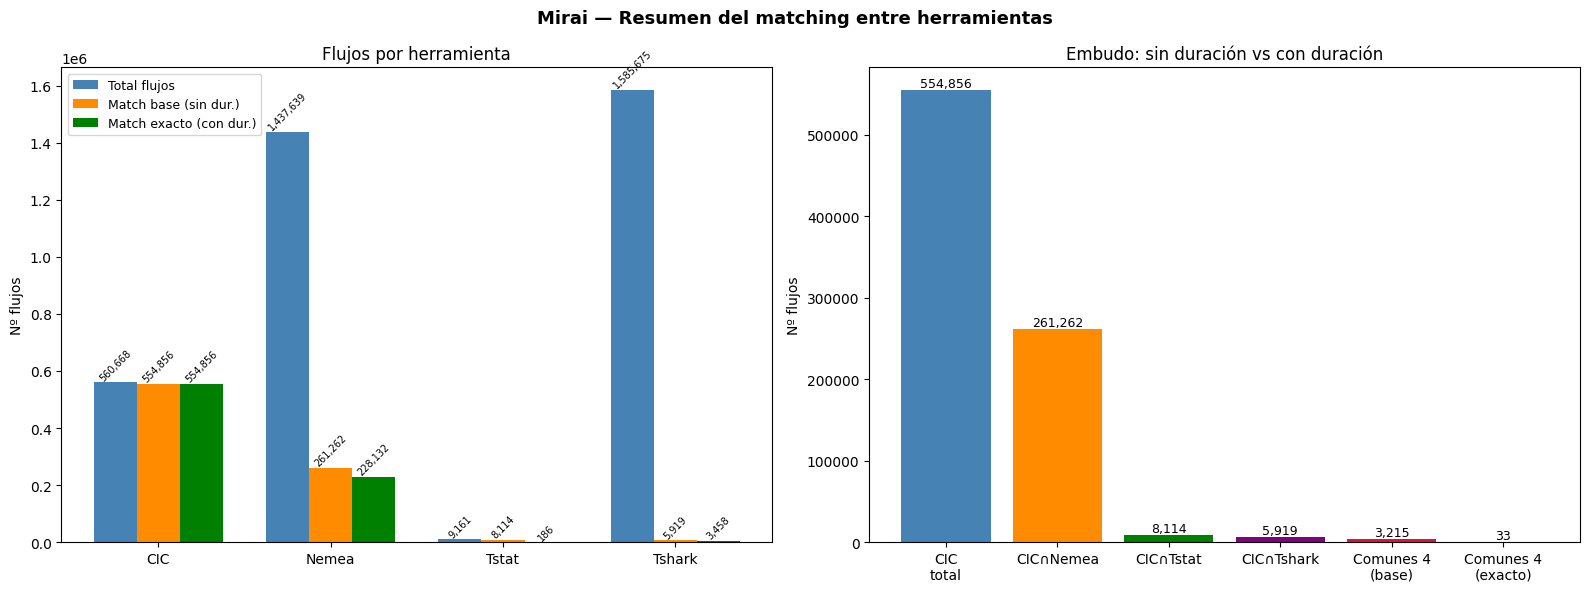

In [17]:
# ============================================================
# CELDA 5.2 — GRÁFICA RESUMEN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mirai — Resumen del matching entre herramientas',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
herramientas = ['CIC', 'Nemea', 'Tstat', 'Tshark']
totales = [len(df_cic), len(df_nemea), len(df_tstat_base), len(df_tshark)]
base    = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base), len(match_tshark_base)]
exactos = [len(cic_keys_base), len(match_nemea_exact), len(match_tstat_exact), len(match_tshark_exact)]

x, width = np.arange(len(herramientas)), 0.25
b1 = ax1.bar(x - width, totales, width, label='Total flujos',            color='steelblue')
b2 = ax1.bar(x,         base,    width, label='Match base (sin dur.)',   color='darkorange')
b3 = ax1.bar(x + width, exactos, width, label='Match exacto (con dur.)', color='green')
ax1.set_title('Flujos por herramienta')
ax1.set_ylabel('N\u00ba flujos')
ax1.set_xticks(x)
ax1.set_xticklabels(herramientas)
ax1.legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f'{h:,}', ha='center', va='bottom', fontsize=7, rotation=45)

ax2 = axes[1]
labels2 = ['CIC\ntotal','CIC\u2229Nemea','CIC\u2229Tstat','CIC\u2229Tshark',
           'Comunes 4\n(base)','Comunes 4\n(exacto)']
values2 = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base),
           len(match_tshark_base), len(base_4), len(exact_4)]
colors2 = ['steelblue','darkorange','green','purple','crimson','darkred']
bars2 = ax2.bar(labels2, values2, color=colors2)
ax2.set_title('Embudo: sin duración vs con duración')
ax2.set_ylabel('N\u00ba flujos')
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELDA 5.3 — EXTRACCIÓN FINAL: 4 CSVs CON TODAS LAS COLUMNAS
# ============================================================

OUTPUT_DIR = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/Mirai')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLS_AUX_CIC = ['archivo_origen','time_sec','flow_dur_ms','key_base','key_exact']

COLS_AUX_NEMEA = ['TIME_FIRST_limpio','TIME_LAST_limpio',
                  'TIME_FIRST_dt','TIME_LAST_dt',
                  'TIME_FIRST_utc2','TIME_LAST_utc2',
                  'SRC_IP_norm','DST_IP_norm',
                  'time_sec','flow_dur_us','flow_dur_ms',
                  'key_base_dir','key_base_inv',
                  'key_exact_dir','key_exact_inv','_key']

COLS_AUX_TSTAT = ['first_utc2','flow_dur_us','flow_dur_ms',
                  'time_sec','key_base_dir','key_base_inv',
                  '_key','proto_num','first_dt']

COLS_AUX_TSHARK = ['start_dt','start_utc2','flow_dur_us','flow_dur_ms',
                   'time_sec','key_base_dir','key_base_inv',
                   'key_exact_dir','key_exact_inv','proto_num','archivo_origen','_key']

# ── NEMEA
df_nemea['_key'] = None
df_nemea.loc[df_nemea['key_base_dir'].isin(base_4), '_key'] = \
    df_nemea.loc[df_nemea['key_base_dir'].isin(base_4), 'key_base_dir']
df_nemea.loc[df_nemea['key_base_inv'].isin(base_4) & df_nemea['_key'].isna(), '_key'] = \
    df_nemea.loc[df_nemea['key_base_inv'].isin(base_4) & df_nemea['_key'].isna(), 'key_base_inv']

df_nemea_4 = df_nemea[df_nemea['_key'].isin(base_4)].copy()
df_nemea_4 = df_nemea_4.drop_duplicates(subset=['_key'], keep='first')
claves_nemea_final = set(df_nemea_4['_key'])
df_nemea_4 = df_nemea_4.drop(columns=COLS_AUX_NEMEA, errors='ignore').reset_index(drop=True)
print(f'Nemea: {len(df_nemea_4):,} filas')

# ── TSTAT
df_tstat_base['_key'] = None
df_tstat_base.loc[df_tstat_base['key_base_dir'].isin(base_4), '_key'] = \
    df_tstat_base.loc[df_tstat_base['key_base_dir'].isin(base_4), 'key_base_dir']
df_tstat_base.loc[df_tstat_base['key_base_inv'].isin(base_4) & df_tstat_base['_key'].isna(), '_key'] = \
    df_tstat_base.loc[df_tstat_base['key_base_inv'].isin(base_4) & df_tstat_base['_key'].isna(), 'key_base_inv']

idx_tstat_match = df_tstat_base[df_tstat_base['_key'].isin(base_4)].index
idx_tstat_match = idx_tstat_match[~pd.Series(idx_tstat_match).duplicated(keep='first').values]

df_tstat_full = pd.concat([df_tcp_tstat, df_udp_tstat], ignore_index=True)
df_tstat_4 = df_tstat_full.loc[idx_tstat_match].copy()
df_tstat_4['_key'] = df_tstat_base.loc[idx_tstat_match, '_key'].values
df_tstat_4 = df_tstat_4.drop_duplicates(subset=['_key'], keep='first')
claves_tstat_final = set(df_tstat_4['_key'])
df_tstat_4 = df_tstat_4.drop(columns=COLS_AUX_TSTAT, errors='ignore').reset_index(drop=True)
print(f'Tstat: {len(df_tstat_4):,} filas')

# ── TSHARK
df_tshark['_key'] = None
df_tshark.loc[df_tshark['key_base_dir'].isin(base_4), '_key'] = \
    df_tshark.loc[df_tshark['key_base_dir'].isin(base_4), 'key_base_dir']
df_tshark.loc[df_tshark['key_base_inv'].isin(base_4) & df_tshark['_key'].isna(), '_key'] = \
    df_tshark.loc[df_tshark['key_base_inv'].isin(base_4) & df_tshark['_key'].isna(), 'key_base_inv']

df_tshark_4 = df_tshark[df_tshark['_key'].isin(base_4)].copy()
df_tshark_4 = df_tshark_4.drop_duplicates(subset=['_key'], keep='first')
claves_tshark_final = set(df_tshark_4['_key'])
df_tshark_4 = df_tshark_4.drop(columns=COLS_AUX_TSHARK, errors='ignore').reset_index(drop=True)
print(f'Tshark: {len(df_tshark_4):,} filas')

# ── CIC
claves_4_real = claves_nemea_final & claves_tstat_final & claves_tshark_final
print(f'\nClaves comunes reales (en las 4): {len(claves_4_real):,}')

df_cic_4 = df_cic[df_cic['key_base'].isin(claves_4_real)].copy()
df_cic_4['Flow Duration'] = pd.to_numeric(df_cic_4['Flow Duration'], errors='coerce')
df_cic_4 = df_cic_4.sort_values('Flow Duration', ascending=False)
df_cic_4 = df_cic_4.drop_duplicates(subset=['key_base'], keep='first')
df_cic_4 = df_cic_4.drop(columns=COLS_AUX_CIC, errors='ignore').reset_index(drop=True)
print(f'CIC:  {len(df_cic_4):,} filas')

# ── Guardar
df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)

print()
print('=' * 60)
print('RESULTADO FINAL — Mirai')
print('=' * 60)
print(f'  CIC:    {len(df_cic_4):>7,} filas x {df_cic_4.shape[1]:>4} columnas')
print(f'  Nemea:  {len(df_nemea_4):>7,} filas x {df_nemea_4.shape[1]:>4} columnas')
print(f'  Tstat:  {len(df_tstat_4):>7,} filas x {df_tstat_4.shape[1]:>4} columnas')
print(f'  Tshark: {len(df_tshark_4):>7,} filas x {df_tshark_4.shape[1]:>4} columnas')
print(f'\n  Guardados en: {OUTPUT_DIR}')
print()
if len(df_cic_4) == len(df_nemea_4) == len(df_tstat_4) == len(df_tshark_4):
    print(f'  \u2713 VERIFICACIÓN CORRECTA — los 4 CSVs tienen {len(df_cic_4):,} flujos')
else:
    print(f'  \u2717 Algún CSV no coincide \u2192 revisar')
    print(f'     CIC {len(df_cic_4):,} / Nemea {len(df_nemea_4):,} / Tstat {len(df_tstat_4):,} / Tshark {len(df_tshark_4):,}')

In [ ]:
# ============================================================
# CELDA 5.4 — ESTANDARIZAR ETIQUETA A 'Mirai' EN LOS 4 CSVs
# Cada herramienta usa nombre de columna distinto y puede tener
# subtipos. Se unifican todos a la clase 'Mirai' para el
# clasificador ML.
# La columna de etiqueta de Nemea se detecta dinámicamente
# (última columna del CSV original).
# ============================================================

LABEL_MAP = {
    'CIC':    (df_cic_4,    'Label'),
    'Nemea':  (df_nemea_4,  col_etiqueta_nemea),
    'Tshark': (df_tshark_4, 'category'),
    'Tstat':  (df_tstat_4,  'etiqueta'),
}

for nombre, (df, col) in LABEL_MAP.items():
    if col in df.columns:
        antes = df[col].value_counts().to_dict()
        df[col] = 'Mirai'
        print(f'{nombre:8s} | {col:20s} \u2192 antes: {antes}')
        print(f'{"":8s} |                       \u2192 ahora: {df[col].unique().tolist()}')
    else:
        print(f'  \u26a0 {nombre}: columna \'{col}\' no encontrada')

# Guardar con etiquetas actualizadas
df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)

print()
print('\u2713 Etiquetas actualizadas y CSVs sobreescritos')